## Импорт библиотек

In [61]:
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import mean_squared_error, r2_score, mean_squared_log_error

from warnings import filterwarnings
filterwarnings('ignore')

In [62]:
df = pd.read_csv('real_estate_data.csv').drop('id',axis=1)

In [63]:
df.head()

,type,sub_type,start_date,end_date,listing_type,tom,building_age,total_floor_count,floor_no,room_count,size,address,furnished,heating_type,price,price_currency
0,Konut,Rezidans,12/10/18,1/9/19,2,30,0,20 ve üzeri,2,2+1,90.0,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,3500.0,TRY
1,Konut,Daire,2/13/19,NaN,1,14,0,20 ve üzeri,20 ve üzeri,1+0,43.0,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,490000.0,TRY
2,Konut,Daire,10/9/18,11/8/18,1,30,0,1,Yüksek Giriş,2+1,NaN,Tekirdağ/Çorlu/Reşadiye,NaN,Fancoil,155000.0,TRY
3,Konut,Rezidans,9/10/18,10/10/18,1,30,3,20 ve üzeri,20 ve üzeri,6+1,450.0,İstanbul/Beşiktaş/Levent,NaN,Fancoil,32500000.0,TRY
4,Konut,Rezidans,12/10/18,1/9/19,1,30,0,20 ve üzeri,2,2+1,90.0,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,1450000.0,TRY


### Описание данных

Признаки:
- type - Тип недвижимости
- sub_type - Подгруппа типа недвижимости
- start_date - Дата начала размещения объявления на рынке
- end_date - Дата окончания размещения объявления на рынке
- listing_type - Тип объявления
- tom - Время нахождения на рынке
- building_age - Возраст здания
- total_floor_count - Количество этажей в здании
- room_count - Количество комнат в квартире
- size - Площадь дома
- address - Адрес жилья
- furnished - Наличие мебели
- currency - Валюта цены дома
- floor_no - Информация о номере этажа данного объявления
- heating_type - Различные типы систем отопления

Целевой (искомый) признак:
- price - Цена дома (или аренды)

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 403487 entries, 0 to 403486
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   type               403487 non-null  object 
 1   sub_type           403487 non-null  object 
 2   start_date         403487 non-null  object 
 3   end_date           266298 non-null  object 
 4   listing_type       403487 non-null  int64  
 5   tom                403487 non-null  int64  
 6   building_age       376097 non-null  object 
 7   total_floor_count  375466 non-null  object 
 8   floor_no           368191 non-null  object 
 9   room_count         403487 non-null  object 
 10  size               257481 non-null  float64
 11  address            403487 non-null  object 
 12  furnished          0 non-null       float64
 13  heating_type       375517 non-null  object 
 14  price              402772 non-null  float64
 15  price_currency     402772 non-null  object 
dtypes:

In [65]:
for col in df.columns:
    print('Кол-во пропусков в колонке %s = %d' % (col, df[col].isna().sum()))

Кол-во пропусков в колонке type = 0
Кол-во пропусков в колонке sub_type = 0
Кол-во пропусков в колонке start_date = 0
Кол-во пропусков в колонке end_date = 137189
Кол-во пропусков в колонке listing_type = 0
Кол-во пропусков в колонке tom = 0
Кол-во пропусков в колонке building_age = 27390
Кол-во пропусков в колонке total_floor_count = 28021
Кол-во пропусков в колонке floor_no = 35296
Кол-во пропусков в колонке room_count = 0
Кол-во пропусков в колонке size = 146006
Кол-во пропусков в колонке address = 0
Кол-во пропусков в колонке furnished = 403487
Кол-во пропусков в колонке heating_type = 27970
Кол-во пропусков в колонке price = 715
Кол-во пропусков в колонке price_currency = 715


In [66]:
df['price'] = pd.to_numeric(df['price'], errors='coerce')
def convert_price(row):
    try:
        price = row['price']
        if pd.isna(price):
            return np.nan
        rates = {'USD': 41.26, 'EUR': 48.33, 'GBP': 55.69}
        return price * rates.get(row['price_currency'], 1)
    except:
        return np.nan

df['price'] = df.apply(convert_price, axis=1)
df = df.dropna(subset=['price'])  # Удаляем NaN в цене

In [67]:
df['city'] = df['address'].str.split('/').str[0].fillna('Unknown')
df['district'] = df['address'].str.split('/').str[1].fillna('Unknown')
df['neighborhood'] = df['address'].str.split('/').str[2].fillna('Unknown')

In [68]:
df = df.drop(['furnished', 'type', 'start_date', 'end_date', 'price_currency', 'address'], axis=1)

In [69]:
# Заменям пропуски медианными значениями
df['size'] = df['size'].replace('', np.nan).astype(float)
df['size'].fillna(df['size'].median(), inplace=True)

In [70]:
# Конвертируем building_age в число
df['building_age'] = df['building_age'].replace('0', '0-5 arası').replace('40 ve üzeri', '40').replace('', np.nan)
df['building_age'] = df['building_age'].apply(lambda x: 0 if pd.isna(x) else int(x.split('-')[0]) if 'arası' in str(x) else int(x))

In [71]:
# Конвертируем total_floor_count в число
df['total_floor_count'] = df['total_floor_count'].replace('20 ve üzeri', '20').replace('', np.nan)
df['total_floor_count'] = df['total_floor_count'].apply(lambda x: np.nan if pd.isna(x) else float(x.split('-')[0]) if 'arası' in str(x) else float(x))
df['total_floor_count'].fillna(df['total_floor_count'].median(), inplace=True)

In [72]:
# Конвертируем floor_no в числа
floor_mapping = {
    'Zemin Kat': 0, 'Giriş Katı': 0, 'Yüksek Giriş': 1, 'Bahçe katı': 0,
    'Kot 2': -2, 'Kot1': -1, 'Asma Kat': 0.5, 'Çatı Katı': 100, 'En Üst Kat': 100,
    '20 ve üzeri': 20
}
df['floor_no'] = df['floor_no'].replace(floor_mapping).replace('', np.nan)
df['floor_no'] = pd.to_numeric(df['floor_no'], errors='coerce')
df['floor_no'].fillna(df['floor_no'].median(), inplace=True)

In [73]:
# Конвертируем room_count в числа
def parse_room_count(x):
    if pd.isna(x) or x == '' or x == '+':
        return np.nan
    try:
        parts = x.split('+')
        return sum(int(part) for part in parts if part.strip().isdigit())
    except:
        return np.nan

In [74]:
df['room_count'] = df['room_count'].apply(parse_room_count)
df['room_count'].fillna(df['room_count'].median(), inplace=True)

In [75]:
df['price_per_m2'] = df['price'] / df['size'].clip(lower=1)  # Избегаем деления на 0
df['age_size_interact'] = df['building_age'] * df['size']  # Взаимодействие

# Фильтрация выбросов
df = df[(df['price'] > 1000) & (df['price'] < 1e9)]
df = df[(df['size'] > 10) & (df['size'] < 5000)]

In [76]:
df.duplicated().sum() 

np.int64(12874)

In [77]:
df = df.drop_duplicates().reset_index(drop=True)

In [78]:
# Разделяем на категории
from sklearn.preprocessing import LabelEncoder

In [79]:
categorical_cols = ['sub_type', 'heating_type', 'city', 'district', 'neighborhood']
label_encoders = {}
for col in categorical_cols:
    df[col] = df[col].replace('', np.nan).fillna('Unknown')
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 340014 entries, 0 to 340013
Data columns (total 15 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   sub_type           340014 non-null  int64  
 1   listing_type       340014 non-null  int64  
 2   tom                340014 non-null  int64  
 3   building_age       340014 non-null  int64  
 4   total_floor_count  340014 non-null  float64
 5   floor_no           340014 non-null  float64
 6   room_count         340014 non-null  float64
 7   size               340014 non-null  float64
 8   heating_type       340014 non-null  int64  
 9   price              340014 non-null  float64
 10  city               340014 non-null  int64  
 11  district           340014 non-null  int64  
 12  neighborhood       340014 non-null  int64  
 13  price_per_m2       340014 non-null  float64
 14  age_size_interact  340014 non-null  float64
dtypes: float64(7), int64(8)
memory usage: 38.9 MB


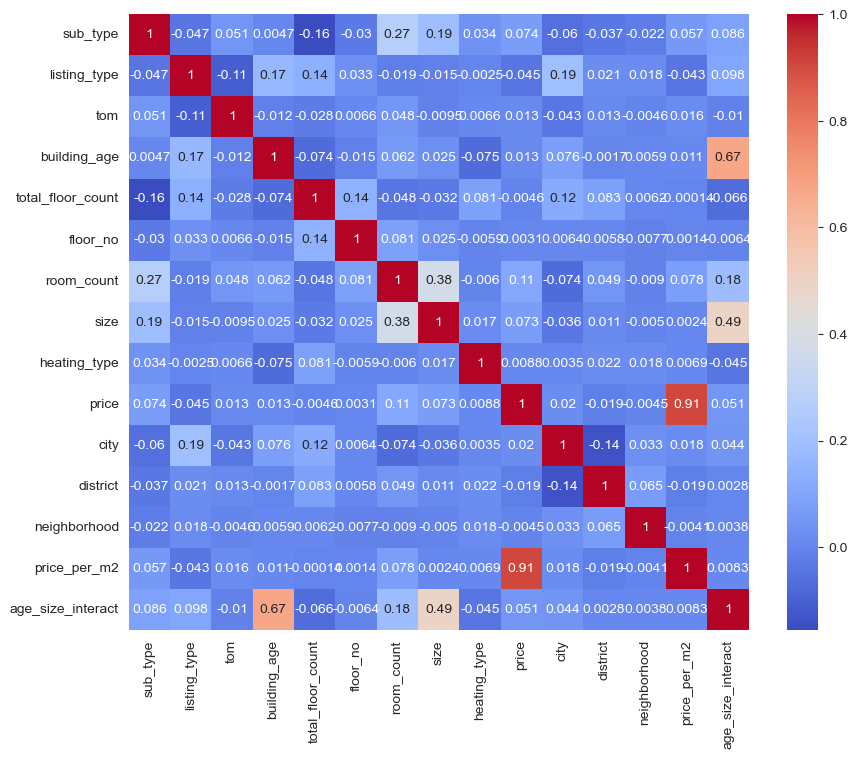

In [81]:
corr_matrix = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

In [82]:
X = df.drop('price', axis=1)
y = df['price']

In [83]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

In [84]:
results = {}
predictions = {}

## Бэггинг

In [85]:
from sklearn.ensemble import RandomForestRegressor

In [86]:
rf_model = RandomForestRegressor(n_estimators=50, max_depth=10, n_jobs=-1, random_state=42)

# Обучение модели
rf_model.fit(X_train, y_train)

# Предсказания на тестовых данных
y_pred = rf_model.predict(X_test)

In [87]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [88]:
results['Random Forest'] = {'MSE': mse, 'R2': r2}
predictions['Random Forest'] = y_pred
print(f"Random Forest - MSE: {mse:.2f}, R2: {r2:.2f}")

Random Forest - MSE: 4335884490618.48, R2: 0.79


## Бустинг

In [89]:
from xgboost import XGBRegressor

In [90]:
# Создаем и обучаем модель градиентного бустинга
xgb_model = XGBRegressor(n_estimators=50, subsample=0.8, early_stopping_rounds=10, random_state=42)
xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)])

# Делаем предсказания на тестовом наборе
y_pred = xgb_model.predict(X_test)

[0]	validation_0-rmse:4083801.43290
[1]	validation_0-rmse:3842657.41746
[2]	validation_0-rmse:3726041.39059
[3]	validation_0-rmse:3670855.54311
[4]	validation_0-rmse:3636445.82085
[5]	validation_0-rmse:3604068.23077
[6]	validation_0-rmse:3603807.46807
[7]	validation_0-rmse:3663924.92807
[8]	validation_0-rmse:3593681.04181
[9]	validation_0-rmse:3588677.52301
[10]	validation_0-rmse:3575139.80321
[11]	validation_0-rmse:3575605.82102
[12]	validation_0-rmse:3590777.59378
[13]	validation_0-rmse:3539566.05890
[14]	validation_0-rmse:3544396.08339
[15]	validation_0-rmse:3559690.63654
[16]	validation_0-rmse:3562857.45067
[17]	validation_0-rmse:3577863.68863
[18]	validation_0-rmse:3529704.57189
[19]	validation_0-rmse:3539012.31600
[20]	validation_0-rmse:3518956.69425
[21]	validation_0-rmse:3531007.66440
[22]	validation_0-rmse:3517182.62712
[23]	validation_0-rmse:3515398.91846
[24]	validation_0-rmse:3515215.30448
[25]	validation_0-rmse:3515996.33880
[26]	validation_0-rmse:3507145.71257
[27]	valida

In [91]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [92]:
results['XGBoost'] = {'MSE': mse, 'R2': r2}
predictions['XGBoost'] = y_pred
print(f"XGBoost - MSE: {mse:.2f}, R2: {r2:.2f}")

XGBoost - MSE: 12111678645455.36, R2: 0.40


## Стекинг

In [93]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge

In [94]:
sr_model = StackingRegressor(
    estimators=[('dt', DecisionTreeRegressor(max_depth=5, random_state=42)), ('ridge', Ridge())],
    final_estimator=LinearRegression(), cv=3
)

In [95]:
sr_model.fit(X_train, y_train)

StackingRegressor(cv=3,
                  estimators=[('dt',
                               DecisionTreeRegressor(max_depth=5,
                                                     random_state=42)),
                              ('ridge', Ridge())],
                  final_estimator=LinearRegression())

In [96]:
y_pred = sr_model.predict(X_test)

In [97]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [98]:
results['Stacking Regressor'] = {'MSE': mse, 'R2': r2}
predictions['Stacking Regressor'] = y_pred
print(f"Stacking Regressor - MSE: {mse:.2f}, R2: {r2:.2f}")

Stacking Regressor - MSE: 6487149425351.66, R2: 0.68


In [99]:
best_model = min(results.items(), key=lambda x: x[1]['MSE'])
print(f"\nBest Model: {best_model[0]} with MSE: {best_model[1]['MSE']:.2f} and R2: {best_model[1]['R2']:.2f}")


Best Model: Random Forest with MSE: 4335884490618.48 and R2: 0.79


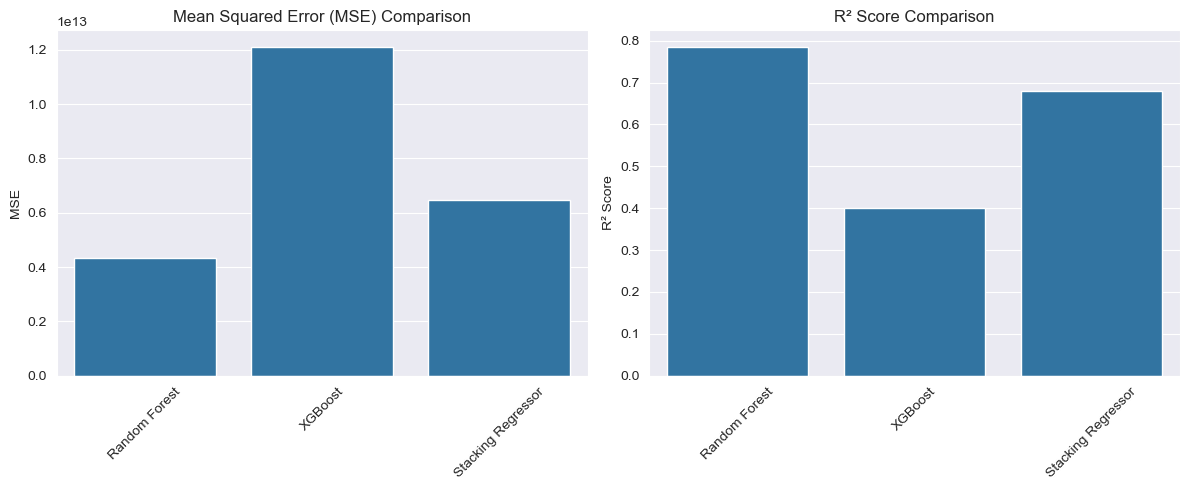

In [100]:
# Visualization 1: Bar Plot for MSE and R2
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# MSE Bar Plot
sns.barplot(x=list(results.keys()), y=[results[model]['MSE'] for model in results], ax=ax1)
ax1.set_title('Mean Squared Error (MSE) Comparison')
ax1.set_ylabel('MSE')
ax1.tick_params(axis='x', rotation=45)

# R2 Bar Plot
sns.barplot(x=list(results.keys()), y=[results[model]['R2'] for model in results], ax=ax2)
ax2.set_title('R² Score Comparison')
ax2.set_ylabel('R² Score')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

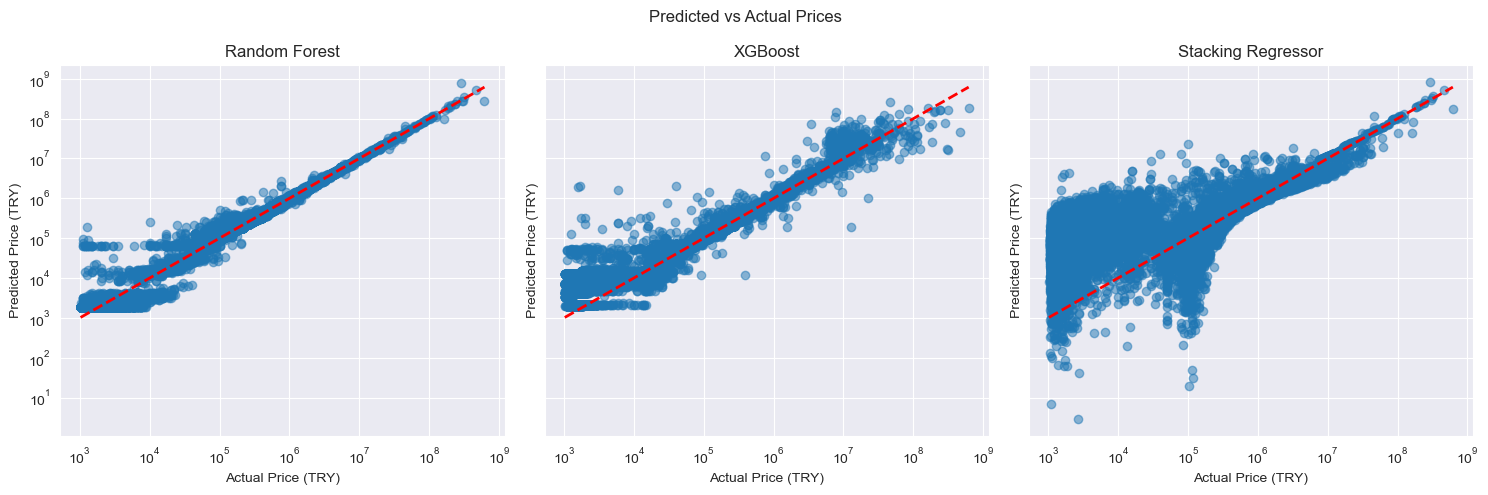

In [101]:
# Visualization 2: Scatter Plots for Predicted vs Actual Prices
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
fig.suptitle('Predicted vs Actual Prices')

for i, (name, y_pred) in enumerate(predictions.items()):
    axes[i].scatter(y_test, y_pred, alpha=0.5)
    axes[i].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    axes[i].set_title(name)
    axes[i].set_xlabel('Actual Price (TRY)')
    axes[i].set_ylabel('Predicted Price (TRY)')
    axes[i].set_xscale('log')
    axes[i].set_yscale('log')

plt.tight_layout()
plt.show()

In [102]:
import pickle

In [103]:
pickle.dump(rf_model, open('rf_moddel.pkl', 'wb'))
pickle.dump(xgb_model, open('xgb_moddel.pkl', 'wb'))
pickle.dump(sr_model, open('sr_moddel.pkl', 'wb'))